## Ejercicio 1
- Implementación del algoritmo genetico
- Optimización del algoritmo mediante optuna
- Comparación contra metodo basado en gradiente

In [3]:
import numpy as np

### Funciones objetivo

In [4]:
import numpy as np

def function_1(x, y):
    r2 = x**2 + y**2
    term1 = np.power(r2, 0.25)
    term2 = np.sin(50 * np.power(r2, 0.1))**2 + 1
    return term1 * term2

def function_2(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

### Codificacion

#### Codif

El proceso para la codificacion consta de:
- Real $\to$ Int
- Int $\to$ Gray

#### $Real \to Int$

Para la transformacion $Real \to Int$, primero normalizaremos los valores, mediante $$\frac{x -L}{U-L}$$ Luego, lo multiplicamos por el numero de representaciones disponibles (Usamos 32 bits para cada cromosoma, ya que supera para ambas funciones un $\epsilon < 10^{-6}$, y es la siguiente potencia de 2 en el exponente luego de 16, que no logra superar un error de $10^{-3}$ en la codificacion).
$$ \frac{x -L}{U-L} * (2^{32} -1)$$Finalmente, realizamos la operacion $int()$ aplicando aqui el error en la codificacion (Ej. Si quedan 2 valores, que dan como resultado 225.1, y 225.6, seran representados con el mismo cromosoma). Por lo que la primera tranformación sera $$ int\left(\frac{x -L}{U-L} * (2^{32} -1)\right)$$


In [5]:
def real_to_int(x, L, U, n_bits):
    x = np.clip(x, L, U) #me aseguro que pertenezca al dominio
    return int(((x - L) / (U - L)) * (2**n_bits - 1))


In [6]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)

3328599653


#### $Int \to Gray$

Para realizar esta conversión, se usa una formula $$G = B \oplus (B \gg 1)$$ Esto es, hacer un xor bit a bit, entre el binario original, y su version desplazada un bit

In [7]:
def int_to_gray(n):
    return n ^ (n >> 1)

In [8]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)
print(bin(entero))
gray = int_to_gray(entero)
print(gray)
print(bin(gray))

3328599653
0b11000110011001100110011001100101
2773833047
0b10100101010101010101010101010111


#### Decodificación

Luego de la evaluación de nuestro algoritmo, debemos decodificar y volver al conjunto real, para poder verificar el fitness que nos da.

- Para pasar de Gray a Int, debemos de realizar una operación en "cascada", por ejemplo:
Si tengo en Gray $0110$, tengo que hacer lo siguiente:
- Dejo el MSB, que sera el MSB tambien en la representación entera.
- Luego, hago un XOR entre el bit 2 de Gray, y el bit 3 en el binario (El MSB), $0 \oplus 1 = 1$, que sera el bit 2 del binario
- Luego, hago un xor entre el bit 1 de Gray, y el 2 del binario, $1 \oplus 1 = 0$, que sera el bit 1 del binario.
- Finalmente, hago un xor entre el bit 0 de Gray, y el 1 del binario, $0 \oplus 0 = 0$, que sera el bit 0 del binario.
Quedandonos $0100$

En vez de hacer esto bit a bit, se usa el siguiente algoritmo por eficiencia (XOR accumulation)

In [9]:
def gray_to_int(n):
    mask = n
    while mask > 0:
        mask >>= 1
        n ^= mask
    return n

Su version vectorizada (muuucho mas rapido)

In [10]:
def gray_to_int_vec(n):
        res = n.copy()
        while np.any(n > 0):
            n >>= 1
            res ^= n
        return res

Y para pasar de Int a Real, despejamos X de nuestra formula para pasar de Real a Int

In [11]:
def int_to_real(idx, L, U, n_bits):
    return L + idx * (U - L) / (2**n_bits - 1) #idx es el indice en la grilla de las representaciones posibles en binario

### Seleccion de poblacion

Para realizar la selección de los individuos, tomo muestras de ventanas de distintos tamaños: $$Window Size = int\left( popsize * (1- \frac{i}{popsize}) \right)$$ Esta ecuación, hace que, a medida que avanza el contador de i, la ventana se acomoda de manera dinamica. $ 1- \frac{i}{popsize}$ nos acomoda el porcentaje de la población de la cual quiero muestrea (i = 0 es toda la poblacion, i = popsize - 1 nos tomas solo el mejor)

In [12]:
def selection_windows(pop_size, fitness, population):
        idx_sorted = np.argsort(fitness) # Ordenar de mejor a peor
        selected_indices = []
        
        for i in range(pop_size):
            window_size = int(pop_size * (1 - (i / pop_size)))
            limit = max(1, window_size)
            
            pick = np.random.randint(0, limit)
            selected_indices.append(idx_sorted[pick])
            
        return population[selected_indices]

Por otro lado, realizamos la implementación que se utiliza para la demostración del teorema de esquemas.

El teorema de esquemas nos dice que el número esperado de ejemplares de un esquema $H$ en la generación siguiente es:$$E[m(H, t+1)] = m(H, t) \frac{f(H)}{\bar{f}}$$Para que esta igualdad se mantenga en la práctica, la probabilidad de que un individuo $i$ sea seleccionado ($p_i$) debe ser:$$p_i = \frac{f_i}{\sum_{j=1}^{N} f_j}$$ (Es la unica manera de que la seleccion sea funcion lineal de la aptitud, con otros puedo castigar demasiado)

In [13]:
def selection_proportional(n_pop, fitness, population):
    #selección por ruleta (Fitness Proportional Selection) 
    # El individuo con el fitness más alto (peor) debe tener la probabilidad más baja.
    f_max = np.max(fitness)
    f_min = np.min(fitness)
    
    # f_trans = (Peor_Fitness - Fitness_i) + Offset
    # El offset evita que el peor individuo tenga probabilidad 0 absoluta,
    f_trans = (f_max - fitness) + (f_max - f_min) * 0.05 + 1e-9
    
    # calculo de probabilidades según el Teorema de Esquemas
    # p_i = f_i / sum(f)
    total_fitness = np.sum(f_trans)
    probs = f_trans / total_fitness
    
    # muestreo segun probabilidades
    indices = np.arange(len(population))
    selected_indices = np.random.choice(indices, size=n_pop, p=probs)
    
    return population[selected_indices]

#### Cruza, mutación y reemplazo

Para la cruza, vamos a usar la cruza de 2 puntos (Cortamos una parte intermedia de un cromosoma de un padre, y la intercambiamos con la del otro padre)

In [14]:
def crossover_2point(p1, p2, pc, chromosome_bits = 32):
        if np.random.rand() < pc:
            points_x = sorted(np.random.choice(range(chromosome_bits), 2, replace=False))
            points_y = [points_x[0] +chromosome_bits, points_x[1] +chromosome_bits]
            c1_x = np.concatenate([p1[:points_x[0]], p2[points_x[0]:points_x[1]], p1[points_x[1]:chromosome_bits]])
            c2_x = np.concatenate([p2[:points_x[0]], p1[points_x[0]:points_x[1]], p2[points_x[1]:chromosome_bits]])
            c1_y = np.concatenate([p1[chromosome_bits:points_y[0]], p2[points_y[0]:points_y[1]], p1[points_y[1]:]])
            c2_y = np.concatenate([p2[chromosome_bits:points_y[0]], p1[points_y[0]:points_y[1]], p2[points_y[1]:]])
            c1 = np.concatenate([c1_x,c1_y])
            c2 = np.concatenate([c2_x,c2_y])
            return c1, c2
        return p1.copy(), p2.copy()

Para la mutación, dada una probabilidad, vamos a hacer un flip de la mutación

In [15]:
def mutate(individual, pm, total_bits=64):
    if np.random.rand() < pm:
        # Selecciona un índice aleatorio en todo el largo del cromosoma (x + y)
        idx = np.random.randint(0, total_bits)
        
        # Flip del bit: 0 -> 1 o 1 -> 0
        individual[idx] = 1 - individual[idx]
        
    return individual

In [16]:
def get_elites(population, fitness, n_elites):
    """
    Extrae los n mejores individuos de la población.
    """
    # Obtenemos los índices que ordenarían el fitness de mayor a menor
    elite_indices = np.argsort(fitness)[:n_elites]
    return population[elite_indices].copy()

### Algoritmo y evaluacion

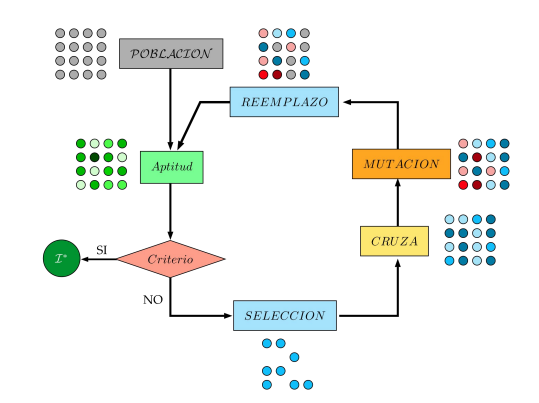

In [17]:
def evaluar_fitness(individual, L, U, funcion_objetivo,n_bits_per_var):   
    # 2. Separar el cromosoma en x e y
    # El individuo es un array de bits de tamaño 64
    bits_x = individual[:n_bits_per_var]
    bits_y = individual[n_bits_per_var:]
    # Convertir arrays de bits a un solo entero decimal (en formato Gray)
    # necesito que las operaciones bit a bit (>>, ^) funcionen
    int_gray_x = int("".join(bits_x.astype(str)), 2)
    int_gray_y = int("".join(bits_y.astype(str)), 2)
    
    idx_x = gray_to_int(int_gray_x)
    idx_y = gray_to_int(int_gray_y)
    
    x_real = int_to_real(idx_x, L, U, n_bits_per_var)
    y_real = int_to_real(idx_y, L, U, n_bits_per_var)
    
    return funcion_objetivo(x_real, y_real)

El tema de hacer esto con un string hace cuello de botella, voy a terminar usando esto.

In [18]:
def evaluar_fitness_vec(population, L, U,funcion_objetivo, n_bits_per_var):
    # population es (tamano_muestra, 64)
    n_bits = n_bits_per_var
    
    # Convertir bits a enteros usando potencias de 2 (esto me soluciona el cuello de botella, paso directamente)
    powers = 2 ** np.arange(n_bits)[::-1]
    
    # Separar x e y
    gray_x = population[:, :n_bits].dot(powers)
    gray_y = population[:, n_bits:].dot(powers)

    idx_x = gray_to_int_vec(gray_x)
    idx_y = gray_to_int_vec(gray_y)
    
    # Escalar a real
    x_real = L + idx_x * (U - L) / (2**n_bits - 1) #no llamo a la funcion
    y_real = L + idx_y * (U - L) / (2**n_bits - 1)
    
    return funcion_objetivo(x_real, y_real)

In [19]:
def run_evolution(poblacion_inicial, tamano_muestra ,select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):

    initial_n = poblacion_inicial
    massive_pop = np.random.randint(0, 2, (initial_n, n_bits))
    fitness_massive = np.array([evaluar_fitness(ind, L, U, funcion_objetivo,n_bits//2) for ind in massive_pop])
    population = select_method(tamano_muestra, fitness_massive, massive_pop)
    history = []
    for gen in range(n_gen):
        # 1. Evaluar a todos
        fitness = np.array([evaluar_fitness(ind, L, U, funcion_objetivo,n_bits//2) for ind in population])
        mejor_fitness_actual = np.min(fitness)
        history.append(mejor_fitness_actual)
        # 2. Elitismo: Guardar a los mejores directamente
        new_population = []
        elites = get_elites(population, fitness, n_elites)
        new_population.extend(elites)
        
        # Genero el "mating pool"
        # Esta es la clave: generamos los tamano_muestra padres aquí
        mating_pool = select_method(tamano_muestra, fitness, population)
        
        # 4. Cruce y Mutación
        # Usamos los padres del pool para crear los hijos que faltan
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            # Tomamos dos padres del pool
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce (n_bits // 2 porque el individuo tiene x e y)
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación de un bit y guardado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2
        
        # 5. Reemplazo total de la población
        population = np.array(new_population)
        
        if gen % 10 == 0:
            print(f"Gen {gen} | Mejor Fitness: {np.min(fitness):.6f}")

    return population, history

En su version vectorizada

In [20]:
def run_evolution_vec(poblacion_inicial, tamano_muestra ,select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):

    initial_n = poblacion_inicial
    massive_pop = np.random.randint(0, 2, (initial_n, n_bits))
    fitness_massive = evaluar_fitness_vec(massive_pop, L, U, funcion_objetivo,n_bits//2)
    population = select_method(tamano_muestra, fitness_massive, massive_pop)
    history = []
    for gen in range(n_gen):
        # 1. Evaluar a todos
        fitness = evaluar_fitness_vec(population, L, U,funcion_objetivo, n_bits//2)
        # Guardamos el mejor fitness encontrado en esta generación
        mejor_fitness_actual = np.min(fitness)
        history.append(mejor_fitness_actual)
        
        # 2. Elitismo: Guardar a los mejores directamente
        new_population = []
        elites = get_elites(population, fitness, n_elites)
        new_population.extend(elites)
        
        # Genero el "mating pool"
        # Esta es la clave: generamos los tamano_muestra padres aquí
        mating_pool = select_method(tamano_muestra, fitness, population)
        
        # 4. Cruce y Mutación
        # Usamos los padres del pool para crear los hijos que faltan
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            # Tomamos dos padres del pool
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce (n_bits // 2 porque el individuo tiene x e y)
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación de un bit y guardado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2
        
        # 5. Reemplazo total de la población
        population = np.array(new_population)
        
        if gen % 10 == 0:
            print(f"Gen {gen} | Mejor Fitness: {np.min(fitness):.6f}")

    return population, history

In [21]:
# Parámetros
poblacion_inicial = 10000
muestra_poblacion = 500
generaciones = 100
total_bits = 64 # 32 para x + 32 para y
prob_cruce = 0.8
prob_mutacion = 0.01 # Probabilidad por individuo
elites_por_gen = 2
L =-100
U=100
funcion_objetivo = function_2

# Ejecución
poblacion_final = run_evolution_vec(
    poblacion_inicial=poblacion_inicial,
    tamano_muestra=muestra_poblacion, 
    select_method=selection_proportional,
    n_gen=generaciones, 
    n_bits=total_bits, 
    pc=prob_cruce, 
    pm=prob_mutacion, 
    n_elites=elites_por_gen,
    L=L,
    U=U,
    funcion_objetivo=funcion_objetivo
)

Gen 0 | Mejor Fitness: 159.376448
Gen 10 | Mejor Fitness: 1.243294
Gen 20 | Mejor Fitness: 0.908612
Gen 30 | Mejor Fitness: 0.242710
Gen 40 | Mejor Fitness: 0.096734
Gen 50 | Mejor Fitness: 0.004840
Gen 60 | Mejor Fitness: 0.004357
Gen 70 | Mejor Fitness: 0.003994
Gen 80 | Mejor Fitness: 0.003993
Gen 90 | Mejor Fitness: 0.003963


### Estudio de Hiperparámetros

In [22]:
import numpy as np

def run_evolution_study_vec(poblacion_inicial, tamano_muestra, select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):
    """
    Versión para análisis de hiperparámetros basada en la lógica de población masiva inicial.
    Devuelve: (mejor_fitness_global, generacion_en_que_se_encontro)
    """
    # 1. Inicialización Masiva y Selección de Muestra Inicial
    massive_pop = np.random.randint(0, 2, (poblacion_inicial, n_bits))
    fitness_massive = evaluar_fitness_vec(massive_pop, L, U, funcion_objetivo, n_bits // 2)
    population = select_method(tamano_muestra, fitness_massive, massive_pop)

    best_fitness_overall = np.inf
    best_gen = 0
    
    for gen in range(n_gen):
        # 2. Evaluación Vectorizada (más eficiente que bucles for)
        fitness = evaluar_fitness_vec(population, L, U, funcion_objetivo, n_bits // 2)
        
        # 3. Seguimiento del mejor global
        indice_mejor_actual = np.argmin(fitness)
        mejor_fitness_gen = fitness[indice_mejor_actual]
        
        if mejor_fitness_gen < best_fitness_overall:
            best_fitness_overall = mejor_fitness_gen
            best_gen = gen

        # 4. Elitismo
        new_population = []
        if n_elites > 0:
            elites = get_elites(population, fitness, n_elites)
            new_population.extend(elites)

        # 5. Mating Pool
        mating_pool = select_method(tamano_muestra, fitness, population)

        # 6. Reproducción (Cruce y Mutación)
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce de 2 puntos
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación y agregado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2

        # 7. Actualización de población
        population = np.array(new_population)

    return best_fitness_overall, best_gen

In [23]:
def study_hyperparameter(param_name, param_values, defaults, n_iters=25):
    results = {}
    for val in param_values:
        params = defaults.copy()
        params[param_name] = val

        fitnesses = []
        best_gens = []

        # Formateo de nombre para métodos de selección o valores numéricos
        val_display = val.__name__ if callable(val) else str(val)

        for _ in range(n_iters):
            fit, gen = run_evolution_study_vec(
                poblacion_inicial=params['poblacion_inicial'],
                tamano_muestra=params['tamano_muestra'],
                select_method=params['select_method'],
                n_gen=params['generaciones'],
                n_bits=params['total_bits'],
                pc=params['prob_cruce'],
                pm=params['prob_mutacion'],
                n_elites=params['elites_por_gen'],
                L=params['L'],
                U=params['U'],
                funcion_objetivo=params['funcion_objetivo']
            )
            fitnesses.append(fit)
            best_gens.append(gen)

        results[val] = {
            'fitness_medio':      np.mean(fitnesses),
            'fitness_mediano':    np.median(fitnesses),
            'gen_mejor_media':    np.mean(best_gens),
            'gen_mejor_mediana':  np.median(best_gens),
        }
        
        print(f"  {param_name}={val_display:>20} | "
              f"fit_medio={results[val]['fitness_medio']:.4f}  "
              f"fit_median={results[val]['fitness_mediano']:.4f}  "
              f"gen_media={results[val]['gen_mejor_media']:.1f}")

    return results

In [24]:
RANGOS = {
    'select_method':     [selection_windows, selection_proportional],
    'generaciones':      [10, 25, 50, 100, 200],
    'prob_cruce':        [0.45, 0.5,0.6, 0.7,0.8, 0.9,0.95, 1.0],
    'prob_mutacion':     [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    'elites_por_gen':    [0, 1, 2, 5, 10],
    'total_bits':        [32, 48, 64, 96, 128],
    'tamano_muestra':    [100, 200,400,500,750,900,1000]
}

# La población inicial se mantiene fija aquí para que run_evolution_study_vec pueda operar
DEFAULTS_ESTUDIO = {
    'poblacion_inicial': 20000,     # Valor fijo para el pool masivo inicial
    'tamano_muestra':    200,    
    'select_method':     selection_windows, 
    'generaciones':      50,
    'total_bits':        64,
    'prob_cruce':        0.8,
    'prob_mutacion':     0.01,
    'elites_por_gen':    2,
    'L':                 -2048,
    'U':                 2048,
    'funcion_objetivo':  function_2,
}

In [25]:
import time

# Ejecución del Loop de Estudio
all_results = {}
t_total = time.time()

for param_name, param_values in RANGOS.items():
    print(f"\n{'─'*80}")
    print(f"ANALIZANDO: {param_name}")
    print(f"{'─'*80}")
    all_results[param_name] = study_hyperparameter(param_name, param_values, DEFAULTS_ESTUDIO, n_iters=10)


────────────────────────────────────────────────────────────────────────────────
ANALIZANDO: select_method
────────────────────────────────────────────────────────────────────────────────


  select_method=   selection_windows | fit_medio=124.3983  fit_median=53.4308  gen_media=46.5
  select_method=selection_proportional | fit_medio=474.0059  fit_median=436.4203  gen_media=46.1

────────────────────────────────────────────────────────────────────────────────
ANALIZANDO: generaciones
────────────────────────────────────────────────────────────────────────────────
  generaciones=                  10 | fit_medio=239.2807  fit_median=89.4705  gen_media=8.9
  generaciones=                  25 | fit_medio=297.2199  fit_median=127.2074  gen_media=22.9
  generaciones=                  50 | fit_medio=57.2175  fit_median=32.5030  gen_media=46.1
  generaciones=                 100 | fit_medio=126.7554  fit_median=81.3462  gen_media=95.2
  generaciones=                 200 | fit_medio=246.1383  fit_median=35.0425  gen_media=195.2

────────────────────────────────────────────────────────────────────────────────
ANALIZANDO: prob_cruce
───────────────────────────────────────────────────

In [26]:
import pandas as pd

for param_name, results in all_results.items():
    print(f"\n{'═'*70}")
    print(f"  Hiperparámetro: {param_name}")
    print(f"{'═'*70}")
    rows = []
    for val, stats in results.items():
        rows.append({
            param_name:              val,
            'Fitness Medio':         round(stats['fitness_medio'],        6),
            'Fitness Mediano':       round(stats['fitness_mediano'],      6),
            'Gen. Mejor (Media)':    round(stats['gen_mejor_media'],      2),
            'Gen. Mejor (Mediana)':  round(stats['gen_mejor_mediana'],    1),
        })
    df = pd.DataFrame(rows).set_index(param_name)
    print(df.to_string())


══════════════════════════════════════════════════════════════════════
  Hiperparámetro: select_method
══════════════════════════════════════════════════════════════════════
                                                         Fitness Medio  Fitness Mediano  Gen. Mejor (Media)  Gen. Mejor (Mediana)
select_method                                                                                                                    
<function selection_windows at 0x000002A6FF840720>          124.398321        53.430768                46.5                  47.0
<function selection_proportional at 0x000002A6E8FC6340>     474.005935       436.420250                46.1                  47.0

══════════════════════════════════════════════════════════════════════
  Hiperparámetro: generaciones
══════════════════════════════════════════════════════════════════════
              Fitness Medio  Fitness Mediano  Gen. Mejor (Media)  Gen. Mejor (Mediana)
generaciones                                

### Comparacion contra Metodo de gradiente

In [27]:
import optuna

def objective(trial):
    # Sugerencias dinámicas de parámetros
    pc = trial.suggest_float("pc", 0.6, 0.95)
    pm = trial.suggest_float("pm", 0.001, 0.05, log=True)
    n_elites = trial.suggest_int("n_elites", 1, 5)
    metodo = trial.suggest_categorical("metodo", ["proportional", "windows"])
    tamano_muestra= trial.suggest_int("tamano_muestra",100,1000)
    
    sel_func = selection_proportional if metodo == "proportional" else selection_windows

    # Ejecutamos 5 réplicas para reducir el ruido estadístico
    replicas = 5
    final_scores = []
    for _ in range(replicas):
        _, history = run_evolution_vec(
            poblacion_inicial=20000, tamano_muestra=tamano_muestra, select_method=sel_func,
            n_gen=80, n_bits=64, pc=pc, pm=pm, n_elites=n_elites, 
            L=-2048, U=2048, funcion_objetivo=function_2
        )
        final_scores.append(history[-1])
    
    return np.mean(final_scores)

# Ejecutar la optimización
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) # Prueba 100 combinaciones

d:\existencia\facu cosa\metah\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-13 21:31:57,699] A new study created in memory with name: no-name-35efb09a-6d96-4b49-be62-0f6fa84a6a30


Gen 0 | Mejor Fitness: 429.977569
Gen 10 | Mejor Fitness: 4.174563
Gen 20 | Mejor Fitness: 3.873619
Gen 30 | Mejor Fitness: 3.873564
Gen 40 | Mejor Fitness: 3.850909
Gen 50 | Mejor Fitness: 3.850909
Gen 60 | Mejor Fitness: 3.850909
Gen 70 | Mejor Fitness: 3.830532
Gen 0 | Mejor Fitness: 3825.619019
Gen 10 | Mejor Fitness: 112.272381
Gen 20 | Mejor Fitness: 112.271348
Gen 30 | Mejor Fitness: 112.271341
Gen 40 | Mejor Fitness: 112.271088
Gen 50 | Mejor Fitness: 112.270956
Gen 60 | Mejor Fitness: 112.270395
Gen 70 | Mejor Fitness: 112.269649
Gen 0 | Mejor Fitness: 7740.163639
Gen 10 | Mejor Fitness: 27.350968
Gen 20 | Mejor Fitness: 27.243159
Gen 30 | Mejor Fitness: 27.243137
Gen 40 | Mejor Fitness: 27.243137
Gen 50 | Mejor Fitness: 27.236061
Gen 60 | Mejor Fitness: 27.232055
Gen 70 | Mejor Fitness: 27.231197
Gen 0 | Mejor Fitness: 399.900157
Gen 10 | Mejor Fitness: 250.154641
Gen 20 | Mejor Fitness: 250.146267
Gen 30 | Mejor Fitness: 250.145407
Gen 40 | Mejor Fitness: 250.144859
Gen 50 |

[I 2026-05-13 21:32:01,103] Trial 0 finished with value: 96.48394653284922 and parameters: {'pc': 0.8065446188903402, 'pm': 0.00476292709507951, 'n_elites': 2, 'metodo': 'windows', 'tamano_muestra': 520}. Best is trial 0 with value: 96.48394653284922.


Gen 60 | Mejor Fitness: 88.950962
Gen 70 | Mejor Fitness: 88.949033
Gen 0 | Mejor Fitness: 5379241.413612
Gen 10 | Mejor Fitness: 1960.247247
Gen 20 | Mejor Fitness: 709.810790
Gen 30 | Mejor Fitness: 709.810777
Gen 40 | Mejor Fitness: 606.974680
Gen 50 | Mejor Fitness: 606.974680
Gen 60 | Mejor Fitness: 606.974680
Gen 70 | Mejor Fitness: 606.971826
Gen 0 | Mejor Fitness: 2561995.588020
Gen 10 | Mejor Fitness: 472634.793580
Gen 20 | Mejor Fitness: 270.182706
Gen 30 | Mejor Fitness: 249.502699
Gen 40 | Mejor Fitness: 10.780875
Gen 50 | Mejor Fitness: 1.613501
Gen 60 | Mejor Fitness: 0.053263
Gen 70 | Mejor Fitness: 0.053121
Gen 0 | Mejor Fitness: 3366233.548995
Gen 10 | Mejor Fitness: 2014037.486377
Gen 20 | Mejor Fitness: 29908.269367
Gen 30 | Mejor Fitness: 1739.076122
Gen 40 | Mejor Fitness: 1531.348339
Gen 50 | Mejor Fitness: 882.432756
Gen 60 | Mejor Fitness: 882.236872
Gen 70 | Mejor Fitness: 881.999235
Gen 0 | Mejor Fitness: 152323.406625
Gen 10 | Mejor Fitness: 82400.094114
Gen 

[I 2026-05-13 21:32:02,832] Trial 1 finished with value: 347.31796443642094 and parameters: {'pc': 0.8250745333576128, 'pm': 0.001227334838507443, 'n_elites': 1, 'metodo': 'proportional', 'tamano_muestra': 266}. Best is trial 0 with value: 96.48394653284922.


...

[I 2026-05-13 21:35:14,466] Trial 47 finished with value: 66.17678727292287 and parameters: {'pc': 0.7572112788093682, 'pm': 0.008007669926863272, 'n_elites': 4, 'metodo': 'windows', 'tamano_muestra': 781}. Best is trial 4 with value: 5.459329194334831.


Gen 0 | Mejor Fitness: 91682.696916
Gen 10 | Mejor Fitness: 587.954124
Gen 20 | Mejor Fitness: 559.740288
Gen 30 | Mejor Fitness: 456.271117
Gen 40 | Mejor Fitness: 456.126874
Gen 50 | Mejor Fitness: 455.942967
Gen 60 | Mejor Fitness: 213.696301
Gen 70 | Mejor Fitness: 213.692270
Gen 0 | Mejor Fitness: 27524.297295
Gen 10 | Mejor Fitness: 4113.532182
Gen 20 | Mejor Fitness: 207.628671
Gen 30 | Mejor Fitness: 173.844064
Gen 40 | Mejor Fitness: 45.838377
Gen 50 | Mejor Fitness: 45.838377
Gen 60 | Mejor Fitness: 45.591654
Gen 70 | Mejor Fitness: 28.114880
Gen 0 | Mejor Fitness: 5786969.272963
Gen 10 | Mejor Fitness: 10261.412965
Gen 20 | Mejor Fitness: 530.983884
Gen 30 | Mejor Fitness: 530.445895
Gen 40 | Mejor Fitness: 51.196985
Gen 50 | Mejor Fitness: 5.193469
Gen 60 | Mejor Fitness: 0.475693
Gen 70 | Mejor Fitness: 0.458936
Gen 0 | Mejor Fitness: 633535.753328
Gen 10 | Mejor Fitness: 12291.774633
Gen 20 | Mejor Fitness: 9092.063694
Gen 30 | Mejor Fitness: 1474.740966
Gen 40 | Mejor Fi

[I 2026-05-13 21:35:16,638] Trial 48 finished with value: 247.03377747356572 and parameters: {'pc': 0.9382708510175092, 'pm': 0.0012494988557456258, 'n_elites': 1, 'metodo': 'proportional', 'tamano_muestra': 365}. Best is trial 4 with value: 5.459329194334831.


Gen 70 | Mejor Fitness: 274.312667
Gen 0 | Mejor Fitness: 81452.335180
Gen 10 | Mejor Fitness: 49.425818
Gen 20 | Mejor Fitness: 49.404955
Gen 30 | Mejor Fitness: 49.403848
Gen 40 | Mejor Fitness: 49.403358
Gen 50 | Mejor Fitness: 49.401451
Gen 60 | Mejor Fitness: 49.400856
Gen 70 | Mejor Fitness: 49.400765
Gen 0 | Mejor Fitness: 616.277066
Gen 10 | Mejor Fitness: 11.244342
Gen 20 | Mejor Fitness: 6.116668
Gen 30 | Mejor Fitness: 6.116480
Gen 40 | Mejor Fitness: 6.114956
Gen 50 | Mejor Fitness: 6.114392
Gen 60 | Mejor Fitness: 6.113678
Gen 70 | Mejor Fitness: 6.112757
Gen 0 | Mejor Fitness: 1066.438022
Gen 10 | Mejor Fitness: 349.906112
Gen 20 | Mejor Fitness: 349.899009
Gen 30 | Mejor Fitness: 349.899006
Gen 40 | Mejor Fitness: 349.898976
Gen 50 | Mejor Fitness: 349.898934
Gen 60 | Mejor Fitness: 349.895763
Gen 70 | Mejor Fitness: 349.895488
Gen 0 | Mejor Fitness: 1298.132734
Gen 10 | Mejor Fitness: 46.559493
Gen 20 | Mejor Fitness: 36.662632
Gen 30 | Mejor Fitness: 36.471399
Gen 40 |

[I 2026-05-13 21:35:22,095] Trial 49 finished with value: 88.38790805987682 and parameters: {'pc': 0.7843621371459147, 'pm': 0.004770703476629134, 'n_elites': 2, 'metodo': 'windows', 'tamano_muestra': 888}. Best is trial 4 with value: 5.459329194334831.


In [28]:
# El mejor conjunto de hiperparámetros encontrados
best_params = study.best_params
print(f"Mejores parámetros: {best_params}")

# El valor de la función objetivo para esos parámetros
print(f"Mejor fitness medio: {study.best_value}")

# Acceder a un parámetro específico
pc_optimo = study.best_params['pc']

Mejores parámetros: {'pc': 0.9175043701468716, 'pm': 0.0025580372356810484, 'n_elites': 3, 'metodo': 'windows', 'tamano_muestra': 716}
Mejor fitness medio: 5.459329194334831



Mejores parámetros: {'pc': 0.8121853019838787, 'pm': 0.013706337605577868, 'n_elites': 4, 'metodo': 'windows', 'tamano_muestra': 937}
Mejor fitness medio: 2.910492463653354

In [29]:
df_results = study.trials_dataframe()
df_results.to_csv("optuna_results.csv", index=False)

In [30]:
from scipy.optimize import minimize
import numpy as np

# Definimos el wrapper para que Scipy pueda hablar con tu función x, y
def wrapper_scipy(params):
    x, y = params # Desempaquetado
    return function_2(x, y)

# Configuración de límites (Bounds)
bounds = [(-2048, 2048), (-2048, 2048)]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

N_RUNS = 100
results_ga = []
results_scipy = []


print(f"🚀 Iniciando duelo: AG Optimizado vs L-BFGS-B ({N_RUNS} ejecuciones)...")

for i in range(N_RUNS):
    # --- 1. Ejecución del AG Optimizado ---
    # Usamos n_gen=80 y poblacion_inicial=20000 como definiste en tu trial
    _, history_ga = run_evolution_vec(
        poblacion_inicial=20000, 
        tamano_muestra=937, 
        select_method=selection_windows,
        n_gen=80, 
        n_bits=64, 
        pc=0.8121853019838787, 
        pm=0.013706337605577868, 
        n_elites=4, 
        L=-2048, U=2048, 
        funcion_objetivo=function_2
    )
    results_ga.append(history_ga[-1])

    # --- 2. Ejecución de Scipy (L-BFGS-B) ---
    # Punto inicial aleatorio para cada ejecución para evaluar robustez
    x0 = np.random.uniform(-2048, 2048, 2)
    res = minimize(wrapper_scipy, x0=x0, method='L-BFGS-B', bounds=bounds)
    results_scipy.append(res.fun)

print("✅ Pruebas completadas.")

🚀 Iniciando duelo: AG Optimizado vs L-BFGS-B (100 ejecuciones)...
Gen 0 | Mejor Fitness: 9959.659671
Gen 10 | Mejor Fitness: 4.545170
Gen 20 | Mejor Fitness: 2.623468
Gen 30 | Mejor Fitness: 0.291802
Gen 40 | Mejor Fitness: 0.167703
Gen 50 | Mejor Fitness: 0.161985
Gen 60 | Mejor Fitness: 0.109238
Gen 70 | Mejor Fitness: 0.084604
Gen 0 | Mejor Fitness: 2310.856761
Gen 10 | Mejor Fitness: 40.766865
Gen 20 | Mejor Fitness: 40.641423
Gen 30 | Mejor Fitness: 40.640755
Gen 40 | Mejor Fitness: 40.638281
Gen 50 | Mejor Fitness: 40.638196
Gen 60 | Mejor Fitness: 40.637808
Gen 70 | Mejor Fitness: 40.637808
Gen 0 | Mejor Fitness: 3125.436066
Gen 10 | Mejor Fitness: 143.433109
Gen 20 | Mejor Fitness: 73.346656
Gen 30 | Mejor Fitness: 73.328039
Gen 40 | Mejor Fitness: 73.328039
Gen 50 | Mejor Fitness: 70.520960
Gen 60 | Mejor Fitness: 36.767990
Gen 70 | Mejor Fitness: 34.928086
Gen 0 | Mejor Fitness: 2898.559414
Gen 10 | Mejor Fitness: 398.311934
Gen 20 | Mejor Fitness: 397.131499
Gen 30 | Mejor F

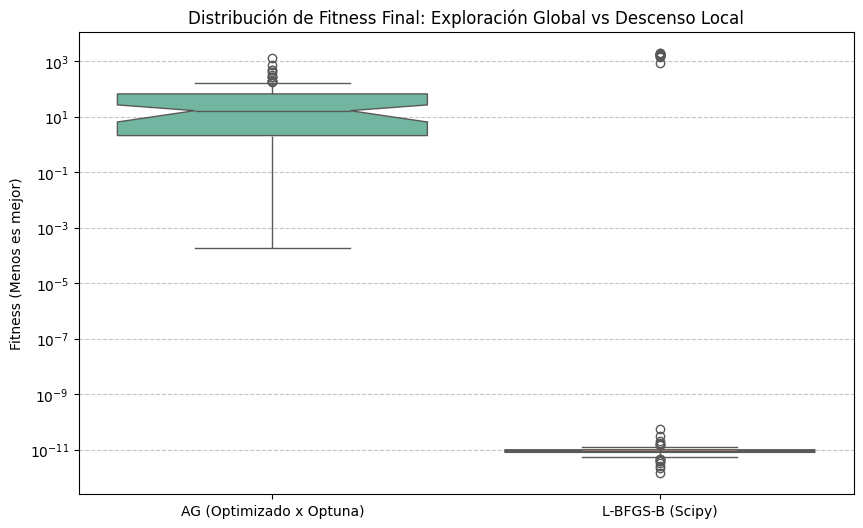


ESTADÍSTICAS FINALES (N=100)
AG -> Media: 78.355554 | Mediana: 16.603786 | Desv. Std: 173.552413
Scipy -> Media: 215.447748 | Mediana: 0.000000 | Desv. Std: 566.176204


In [35]:
# --- Boxplot de Comparación ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=[results_ga, results_scipy], palette="Set2", notch=True)
plt.xticks([0, 1], ['AG (Optimizado x Optuna)', 'L-BFGS-B (Scipy)'])
plt.title('Distribución de Fitness Final: Exploración Global vs Descenso Local')
plt.ylabel('Fitness (Menos es mejor)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Si hay mucha diferencia de escala, activamos escala logarítmica
if np.max(results_ga) / (np.min(results_ga) + 1e-9) > 100:
    plt.yscale('log')

plt.show()

# --- Resumen Estadístico ---
print(f"\n{'='*40}")
print(f"ESTADÍSTICAS FINALES (N={N_RUNS})")
print(f"{'='*40}")
print(f"AG -> Media: {np.mean(results_ga):.6f} | Mediana: {np.median(results_ga):.6f} | Desv. Std: {np.std(results_ga):.6f}")
print(f"Scipy -> Media: {np.mean(results_scipy):.6f} | Mediana: {np.median(results_scipy):.6f} | Desv. Std: {np.std(results_scipy):.6f}")

En comparacion con el algoritmo de gradiente (state of art), le va bastante bien, si vemos las medias, nuestro algoritmo le va bastante bien, lo que sucede, es que el sgd, en esta funcion (banana de Rosenbrock), tiene una precision muy alta, una vez que llego a la zona del minimo, funciona de manera excelente, pero tiene unos outliers muymuy altos.

Esto se puede solucionar mediante algoritmos memeticos! Si le damos chance a refinar, mediante un hill climbing o algun algoritmo sencillo, vamos a conseguir "refinamiento local", logrando complementar la falta de este en los algoritmos geneticos

## Ejercicio 2
- Implementación de PSO
- Comparación contra algoritmo genetico

### Implementación del PSO

In [40]:
class PSO():
    def __init__(self, c1=2, c2=2, w=0.7, strategy='global'):
        self.c1 = c1
        self.c2 = c2
        self.w = w
        self.strategy = strategy
        
    def run(self, function, n_particles, bounds, max_iters=1000):
        """
        bounds = [(x_min, x_max), (y_min, y_max), ...]
        """
        self.bounds = np.array(bounds)
        dim = len(bounds)
        
        #inicializamos las posiciones
        positions = np.random.uniform(
            low=self.bounds[:, 0],  
            high=self.bounds[:, 1],
            size=(n_particles, dim)
        )
        #incializamos las velocidades nulas
        velocities = np.zeros((n_particles, dim))
        
        #calculasmo los fitnes para esas posiciones
        fitness = np.array([function(*p) for p in positions])
        
        pbest_pos = positions.copy() #personal best positions
        pbest_fit = fitness.copy() #personal best fintess
        
        gbest_idx = np.argmin(pbest_fit) #global best index
        gbest_pos = pbest_pos[gbest_idx].copy() #global best position
        gbest_fit = pbest_fit[gbest_idx] #global best fit
        history = []
        
        # Bucle principal
        for _ in range(max_iters):
            # 1. Actualización de movimiento según la estrategia
            for i in range(n_particles):
                if self.strategy == 'local':
                    self._update_local(i, positions, velocities, pbest_pos, pbest_fit)
                elif self.strategy == 'global':
                    self._update_global(i, positions, velocities, pbest_pos, gbest_pos)
            
            # 2. Evaluación de la función objetivo (NFE aumenta aquí)
            fitness = np.array([function(*p) for p in positions])
            
            # 3. Actualización de mejores personales y globales
            for i in range(n_particles):
                if fitness[i] < pbest_fit[i]:
                    pbest_fit[i] = fitness[i]
                    pbest_pos[i] = positions[i].copy()
                    
                    if fitness[i] < gbest_fit:
                        gbest_fit = fitness[i]
                        gbest_pos = positions[i].copy()
            
            # 4. Registro del historial para análisis de convergencia
            history.append(gbest_fit)
        
        # Retornamos la mejor posición, el mejor fitness y el historial
        return gbest_pos, gbest_fit, np.array(history)
    
    def _update_global(self, i, positions, velocities, pbest_pos, gbest_pos):
        dim = len(positions[i])
        r1 = np.random.random(dim)
        r2 = np.random.random(dim)
        
        #actualizamos velocidad y posicion
        velocities[i] = (self.w * velocities[i] + 
                         self.c1 * r1 * (pbest_pos[i] - positions[i]) + 
                         self.c2 * r2 * (gbest_pos - positions[i]))
        
        positions[i] += velocities[i]
        positions[i] = np.clip(positions[i], self.bounds[:, 0], self.bounds[:, 1])
    
    def _update_local(self, i, positions, velocities, pbest_pos, pbest_fit):
        """
        cadaparticula mira el lider de su vecindad
        """
        dim = len(positions[i])
        n_particles = len(positions)
        
        #toplogia de vecindad de radio 1
        left = (i - 1) % n_particles
        right = (i + 1) % n_particles
        
        # mejor de la vecindad
        neighborhood = [left, i, right] #definimos la vecindad

        #buscamos el indice con menor pbest_fit

        best_idx = neighborhood[0] 
        best_fitness = pbest_fit[best_idx]
        for idx in neighborhood:
            if pbest_fit[idx]<best_fitness:
                best_idx = idx
                best_fitness = pbest_fit[idx]
                
        #ya tenemos el lider de la vecindad
        lbest_pos = pbest_pos[best_idx].copy()
        
        r1 = np.random.random(dim)
        r2 = np.random.random(dim)
        
        velocities[i] = (self.w * velocities[i] + 
                         self.c1 * r1 * (pbest_pos[i] - positions[i]) + 
                         self.c2 * r2 * (lbest_pos - positions[i]))
        
        positions[i] += velocities[i]
        positions[i] = np.clip(positions[i], self.bounds[:, 0], self.bounds[:, 1])




In [42]:
pso = PSO(c1=2, c2=2, strategy='global')
best_pos, best_fit,_ = pso.run(function_1, n_particles=30, bounds=[(-10, 10), (-10, 10)], max_iters=1000)
print(f"Mejor posición: {best_pos}, Mejor fitness: {best_fit}")

Mejor posición: [ 1.34463286e-27 -4.21575119e-27], Mejor fitness: 6.652065330429858e-14


Gen 0 | Mejor Fitness: 8280.367653
Gen 10 | Mejor Fitness: 114.153494
Gen 20 | Mejor Fitness: 114.063295
Gen 30 | Mejor Fitness: 114.060401
Gen 40 | Mejor Fitness: 114.059949
Gen 50 | Mejor Fitness: 114.057363
Gen 60 | Mejor Fitness: 114.057095
Gen 70 | Mejor Fitness: 114.054594


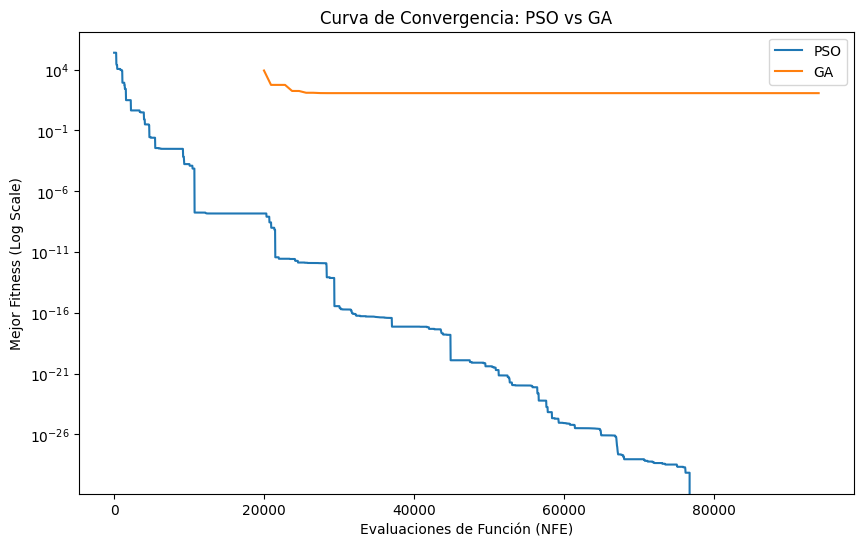

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

best_pos_pso, best_fit_pso, history_pso = pso.run(function_2, n_particles=30, bounds=[(-2048, 2048), (-2048, 2048)], max_iters=3000)

_, history_ga = run_evolution_vec(
    poblacion_inicial=20000, 
    tamano_muestra=937, 
    select_method=selection_windows,
    n_gen=80, 
    n_bits=64, 
    pc=0.8121853019838787, 
    pm=0.013706337605577868, 
    n_elites=4, 
    L=-2048, U=2048, 
    funcion_objetivo=function_2
)

# 3. Visualización de Convergencia
plt.figure(figsize=(10, 6))
# Eje X para PSO: Lineal (30 por iteración)
x_pso = np.arange(len(history_pso)) * 30

# Eje X para GA: Salto inicial de 20k y luego pasos de 937
x_ga = 20000 + (np.arange(len(history_ga)) * 937) 

plt.plot(x_pso, history_pso, label='PSO')
plt.plot(x_ga, history_ga, label='GA')
plt.xlabel('Evaluaciones de Función (NFE)')
plt.ylabel('Mejor Fitness')
plt.yscale('log') 
plt.legend()
plt.yscale('log')
plt.xlabel('Evaluaciones de Función (NFE)')
plt.ylabel('Mejor Fitness (Log Scale)')
plt.legend()
plt.title('Curva de Convergencia: PSO vs GA')
plt.show()

Por mas complejidad que tenga el algoritmo genetico, el pso con su simpleza logra muchos mejores resultados

In [58]:
import time

start = time.perf_counter()
best_pos_pso, best_fit_pso, history_pso = pso.run(function_2, n_particles=30, bounds=[(-2048, 2048), (-2048, 2048)], max_iters=3000)

end = time.perf_counter()
t_pso = end - start

start = time.perf_counter()
_, history_ga = run_evolution_vec(
    poblacion_inicial=20000, 
    tamano_muestra=937, 
    select_method=selection_windows,
    n_gen=80, 
    n_bits=64, 
    pc=0.8121853019838787, 
    pm=0.013706337605577868, 
    n_elites=4, 
    L=-2048, U=2048, 
    funcion_objetivo=function_2
)
end = time.perf_counter()
t_ga = end - start

print(f"PSO: {t_pso:.4f}s | GA: {t_ga:.4f}s")

Gen 0 | Mejor Fitness: 311.998730
Gen 10 | Mejor Fitness: 4.765564
Gen 20 | Mejor Fitness: 4.761705
Gen 30 | Mejor Fitness: 4.761038
Gen 40 | Mejor Fitness: 4.757459
Gen 50 | Mejor Fitness: 4.757426
Gen 60 | Mejor Fitness: 4.755535
Gen 70 | Mejor Fitness: 4.755249
PSO: 1.3854s | GA: 1.2394s


Manteniendo esta relacion de iteraciones, el tiempo es similar, pero el algoritmo genetico queda estancado bastante rapido en optimos locales